In [1]:
import numpy as np
import lightkurve as lk
import matplotlib.pyplot as plt

/Users/aaryanthusoo/Desktop/UCL/Research/.venv/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [ ]:
search_result = lk.search_lightcurve('KIC 2010607', author='Kepler')
#search_result

In [ ]:
lc = search_result[2].download()

In [ ]:
plt.plot(lc["flux"][300:500])
plt.show()

In [6]:
def download_random_kepler_lc_stitched(kic_list, max_tries=10, min_points=1000):
    """
    Pick a random KIC, download ALL available Kepler light curves, stitch into one,
    and return (kic, stitched_lc).

    Parameters
    ----------
    kic_list : list[int]
        List of KIC IDs to sample from.
    max_tries : int
        How many random KICs to try before failing.
    min_points : int
        Minimum number of cadences required after cleaning.

    Returns
    -------
    kic : int
    lc  : lk.LightCurve
        Cleaned, stitched Kepler light curve.
    """
    for _ in range(max_tries):
        kic = int(np.random.choice(kic_list))
        srch = lk.search_lightcurve(f"KIC {kic}", mission="Kepler")

        if len(srch) == 0:
            continue

        try:
            lcc = srch.download_all()
            if lcc is None or len(lcc) == 0:
                continue

            lc = (lcc.stitch()
                    .remove_nans()
                    .remove_outliers(sigma=5)
                    .normalize())

            if len(lc.flux) >= min_points:
                return kic, lc

        except Exception:
            continue

    raise RuntimeError("Failed to download a usable stitched Kepler light curve.")

In [7]:
kic, lc = download_random_kepler_lc_stitched([2010607])

In [3]:
def extract_stellar_variability(lc, window_length=101):
    lc = lc.remove_nans().remove_outliers(sigma=5).normalize()  # important
    flat, trend = lc.flatten(window_length=window_length, return_trend=True)

    # stellar variability as fractional signal around 0
    stellar_var = (trend.flux / np.nanmedian(trend.flux)).value - 1.0
    return stellar_var, trend, flat


In [8]:
stellar_var, trend, flat = extract_stellar_variability(lc)

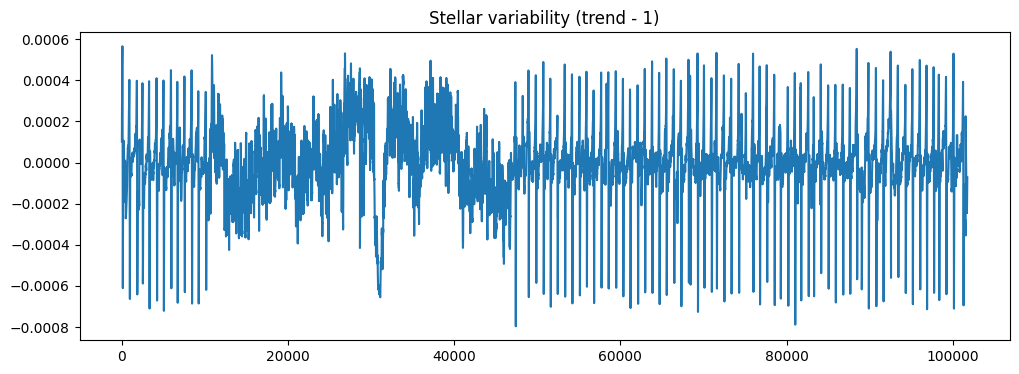

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(np.arange(0, len(stellar_var)), stellar_var)
plt.title("Stellar variability (trend - 1)")
plt.show()

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot()
plt.title("Stellar variability (trend - 1)")
plt.show()